# Giai đoạn 3 — Học phân phối sở thích theo ngành

**Đầu vào:** `02_split/khaosat_train.csv` (574 phiếu thật) — **không đọc file test**.

**Đầu ra:**
- `phan_phoi_theo_nganh.json` — phân phối "sản xuất", học từ cả 574 phiếu train.
- `phan_phoi_theo_fold.json` — phân phối học **riêng cho từng fold**, chỉ dùng phần train của fold đó.

## Mục tiêu

Giai đoạn 4 cần biết *"sinh viên ngành X thường trả lời 10 câu Likert như thế nào?"* để sinh dữ liệu
tổng hợp. Giai đoạn này ước lượng phân phối đó cho từng ngành.

## Hai điểm mấu chốt trong thiết kế

### 1. Phải giữ được **tương quan giữa các câu hỏi**

10 câu Likert **không độc lập** với nhau — người tự đánh giá "tư duy logic" cao thường cũng đánh giá
"tò mò" cao. Nếu chỉ lưu trung bình và độ lệch chuẩn của từng câu rồi sinh dữ liệu bằng 10 phân phối
chuẩn **độc lập**, dữ liệu tổng hợp sẽ có cấu trúc tương quan **phẳng hoàn toàn** — khác hẳn người thật.

Vì vậy ta ước lượng **vector trung bình (10 chiều) + ma trận hiệp phương sai (10×10)**, giữ nguyên
cấu trúc liên hệ giữa các câu.

### 2. Ngành ít mẫu phải "mượn" đặc trưng của khối ngành — **Bayesian Shrinkage**

Ngành ít nhất chỉ có 5 phiếu train. Ước lượng trung bình từ 5 mẫu rất nhiễu, còn ma trận hiệp phương
sai 10×10 từ 5 mẫu thì **suy biến** (không đủ hạng). Cách xử lý là kéo ước lượng của ngành về phía
đặc trưng chung của khối ngành, với $K$ đóng vai trò "số mẫu ảo":

$$\mu_{\text{ngành}} = \frac{n\,\bar{x}_{\text{ngành}} + K\,\mu_{\text{khối}}}{n + K}
\qquad
\Sigma_{\text{ngành}} = \frac{n\,S_{\text{ngành}} + K\,\Sigma_{\text{khối}}}{n + K}$$

Ngành 5 mẫu sẽ nghiêng hẳn về đặc trưng khối; ngành 40 mẫu giữ được nét riêng.
Bản thân $\mu_{\text{khối}}, \Sigma_{\text{khối}}$ cũng được kéo về mức toàn cục theo cùng công thức.

> **Prior lấy từ đâu?** Từ **chính dữ liệu train** (trung bình và hiệp phương sai của khối ngành),
> không phải do người viết đặt tay — nên không đưa giả định chủ quan vào mô hình.

In [1]:
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from pathlib import Path

# ── Thiết lập kiểu biểu đồ dùng chung cho toàn bộ báo cáo ────────────────────
plt.rcParams.update({
    "figure.dpi": 100, "savefig.dpi": 220, "savefig.bbox": "tight",
    "font.family": "DejaVu Sans", "font.size": 11,
    "axes.titlesize": 13, "axes.titleweight": "bold", "axes.titlepad": 14,
    "axes.labelsize": 11, "axes.labelpad": 8,
    "axes.grid": True, "grid.alpha": 0.18, "grid.linestyle": "-", "grid.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.spines.left": False, "axes.edgecolor": "#B0B7BF",
    "figure.facecolor": "white", "axes.facecolor": "white",
    "legend.frameon": False, "legend.fontsize": 10,
    "xtick.labelsize": 10, "ytick.labelsize": 10,
    "xtick.color": "#4A5560", "ytick.color": "#4A5560",
    "axes.labelcolor": "#2C3E50", "text.color": "#2C3E50",
})

# Bảng màu thống nhất
C_THAT  = "#D64550"   # dữ liệu thật
C_GA    = "#2BA84A"   # dữ liệu tổng hợp (GA)
C_XANH  = "#3B7DD8"   # nhấn mạnh chính
C_CAM   = "#E8873A"   # nhấn mạnh phụ
C_TIM   = "#8E5FBF"
C_XAM   = "#AEB6BF"   # nền / mốc so sánh
C_DAM   = "#2C3E50"
C_KHOI  = ["#3B7DD8", "#E8873A", "#8E5FBF", "#19A2A2", "#D64550", "#C9A227", "#5D6D7E"]


def nhan_ngang(ax, gia_tri, fmt="{:,.0f}", lui=0.012, fs=10, mau=None):
    # Ghi số ở cuối mỗi thanh ngang
    lim = ax.get_xlim()[1]
    for i, v in enumerate(gia_tri):
        ax.text(v + lim * lui, i, fmt.format(v), va="center", fontsize=fs,
                fontweight="bold", color=mau or C_DAM)


def nhan_doc(ax, fmt="{:,.0f}", lui=0.02, fs=10):
    # Ghi số trên đầu mỗi cột dọc
    lim = ax.get_ylim()[1]
    for p in ax.patches:
        h = p.get_height()
        if h and abs(h) > 1e-9:
            ax.text(p.get_x() + p.get_width() / 2, h + lim * lui, fmt.format(h),
                    ha="center", va="bottom", fontsize=fs, fontweight="bold", color=C_DAM)


def chu_thich(fig, text, y=None):
    # Dòng chú giải nằm dưới hình — nêu kết luận rút ra từ biểu đồ.
    # Chú giải (legend) đặt ngoài trục bằng bbox_to_anchor y âm có thể thò xuống
    # dưới đáy hình; khi đó phải hạ dòng chú thích xuống dưới nó, nếu không hai
    # bên đè lên nhau (bbox_inches="tight" nới khung chứ không dời chữ ra).
    if y is None:
        y = -0.02
        fig.canvas.draw()
        r = fig.canvas.get_renderer()
        hop_ds = [lg.get_window_extent(r) for lg in fig.legends]
        hop_ds += [ax.get_legend().get_window_extent(r)
                   for ax in fig.axes if ax.get_legend() is not None]
        for hop in hop_ds:
            day = hop.transformed(fig.transFigure.inverted()).y0
            if day < y:
                y = day - 0.035
    fig.text(0.5, y, text, ha="center", va="top", fontsize=10.5,
             color="#5A6672", style="italic", wrap=True)


def luu(fig, thu_muc, ten, chu=None):
    if chu:
        chu_thich(fig, chu)
    fig.savefig(thu_muc / ten, dpi=220, bbox_inches="tight", facecolor="white")
    print(f"   💾 Đã lưu hình: {ten}")

SPLIT_DIR = Path("../data/processed/02_split")
DIST_DIR  = Path("../data/processed/03_distribution")
DIST_DIR.mkdir(parents=True, exist_ok=True)

SEED = 42
np.random.seed(SEED)

K_NGANH, K_KHOI = 10.0, 20.0   # số "mẫu ảo" của prior
VAR_MIN, EIG_MIN = 0.35, 1e-3  # chặn dưới phương sai và trị riêng

LIKERT_COLS = ["likert_nang_dong", "likert_huong_noi", "likert_sang_tao", "likert_logic",
               "likert_to_mo", "likert_thi_nghiem", "likert_moi_truong",
               "likert_dinh_duong", "likert_tranh_luan", "likert_thiet_ke"]
NHAN = ["Năng động", "Hướng nội", "Sáng tạo", "Tư duy logic", "Tò mò",
        "Thí nghiệm", "Môi trường", "Dinh dưỡng", "Tranh luận", "Thiết kế"]
MUC_TIEU_KEYS = ["Đi làm", "Nghiên cứu", "Kinh doanh", "Chưa xác định"]

df_train = pd.read_csv(SPLIT_DIR / "khaosat_train.csv")
TAX = json.load(open(SPLIT_DIR / "nganh_khoi_mapping.json", encoding="utf-8"))
TEN_TO_MA     = {k: int(v) for k, v in TAX["ten_to_ma"].items()}
MA_TO_TEN     = {int(k): v for k, v in TAX["ma_to_ten"].items()}
NGANH_TO_KHOI = {int(k): v for k, v in TAX["nganh_to_khoi"].items()}
TEN_KHOI      = {int(k): v for k, v in TAX["ten_khoi"].items()}
CV = json.load(open(SPLIT_DIR / "cv_folds_real.json", encoding="utf-8"))

assert len(df_train) == CV["n_train_real"]
print(f"Dữ liệu train : {len(df_train)} phiếu thật, {df_train['ma_nganh'].nunique()} ngành, 7 khối")
print(f"Số fold CV    : {len(CV['folds'])}")
print(f"Số mẫu/ngành  : ít nhất {df_train['ma_nganh'].value_counts().min()}, "
      f"nhiều nhất {df_train['ma_nganh'].value_counts().max()}")

Dữ liệu train : 574 phiếu thật, 39 ngành, 7 khối
Số fold CV    : 15
Số mẫu/ngành  : ít nhất 5, nhiều nhất 40


## 1. Hàm ước lượng phân phối

In [2]:
def lam_xac_dinh_duong(cov, var_min=VAR_MIN, eig_min=EIG_MIN):
    # Ép ma trận hiệp phương sai về dạng đối xứng, xác định dương, phương sai không quá nhỏ
    cov = (cov + cov.T) / 2.0
    d = np.sqrt(np.maximum(np.diag(cov), 1e-8))
    corr = np.clip(cov / np.outer(d, d), -0.99, 0.99)
    np.fill_diagonal(corr, 1.0)
    d = np.maximum(d, np.sqrt(var_min))
    cov = corr * np.outer(d, d)
    w, V = np.linalg.eigh(cov)
    if w.min() < eig_min:
        cov = V @ np.diag(np.maximum(w, eig_min)) @ V.T
        cov = (cov + cov.T) / 2.0
    return cov


def uoc_luong_nhom(X, mean_prior, cov_prior, K):
    # Trung bình + hiệp phương sai của nhóm, co ngót về prior với K mẫu ảo
    n = len(X)
    if n == 0:
        return mean_prior.copy(), cov_prior.copy(), 0
    mean = (n * X.mean(axis=0) + K * mean_prior) / (n + K)
    S = np.cov(X, rowvar=False) if n >= 2 else cov_prior
    return mean, lam_xac_dinh_duong((n * S + K * cov_prior) / (n + K)), n


def phan_phoi_rr(series, keys, prior, K):
    # Phân phối rời rạc (mục tiêu nghề nghiệp), co ngót về prior
    n = len(series)
    if n == 0:
        return dict(zip(keys, prior))
    emp = series.value_counts(normalize=True).reindex(keys).fillna(0.0).values
    p = (n * emp + K * np.asarray(prior)) / (n + K)
    return dict(zip(keys, np.round(p / p.sum(), 6)))


def ty_le_nam(series, prior_p, K):
    n = len(series)
    return float(prior_p) if n == 0 else float(np.round(
        (n * float((series == "Nam").mean()) + K * prior_p) / (n + K), 6))


def hoc_phan_phoi(df):
    # Học phân phối 39 ngành từ một tập dòng thật
    Xg = df[LIKERT_COLS].to_numpy(float)
    mean_g = Xg.mean(axis=0)
    cov_g  = lam_xac_dinh_duong(np.cov(Xg, rowvar=False))
    p_nam_g = float((df["gioi_tinh"] == "Nam").mean())
    mt_g = df["muc_tieu_nhan"].value_counts(normalize=True).reindex(MUC_TIEU_KEYS).fillna(0.0)
    mt_g = (mt_g / mt_g.sum()).values

    khoi = {}
    for k in range(7):
        sub = df[df["ma_khoi_nganh"] == k]
        m, c, n = uoc_luong_nhom(sub[LIKERT_COLS].to_numpy(float), mean_g, cov_g, K_KHOI)
        khoi[k] = {"mean": m, "cov": c, "n": n,
                   "p_nam": ty_le_nam(sub["gioi_tinh"], p_nam_g, K_KHOI),
                   "muc_tieu": phan_phoi_rr(sub["muc_tieu_nhan"], MUC_TIEU_KEYS, mt_g, K_KHOI)}

    out = {}
    for ten, ma in TEN_TO_MA.items():
        k = NGANH_TO_KHOI[ma]; pk = khoi[k]
        sub = df[df["ma_nganh"] == ma]
        m, c, n = uoc_luong_nhom(sub[LIKERT_COLS].to_numpy(float), pk["mean"], pk["cov"], K_NGANH)
        out[str(ma)] = {
            "ten_nganh": ten, "khoi_nganh_id": k, "ten_khoi_nganh": TEN_KHOI[k],
            "so_mau_thuc_te": int(n),
            "trong_so_prior": float(np.round(K_NGANH / (n + K_NGANH), 4)),
            "likert_mean": np.round(m, 4).tolist(),
            "likert_cov":  np.round(c, 4).tolist(),
            "gioi_tinh_ty_le_nam": ty_le_nam(sub["gioi_tinh"], pk["p_nam"], K_NGANH),
            "muc_tieu_phan_phoi": {kk: float(vv) for kk, vv in phan_phoi_rr(
                sub["muc_tieu_nhan"], MUC_TIEU_KEYS, list(pk["muc_tieu"].values()), K_NGANH).items()},
        }
    return out, khoi, {"mean": mean_g, "cov": cov_g}


phan_phoi, khoi_stats, toan_cuc = hoc_phan_phoi(df_train)
print(f"✅ Đã học phân phối cho {len(phan_phoi)} ngành")

✅ Đã học phân phối cho 39 ngành


In [3]:
bang = pd.DataFrame([{
    "Ngành": d["ten_nganh"], "Khối": d["ten_khoi_nganh"],
    "Số mẫu": d["so_mau_thuc_te"],
    "Trọng số prior (%)": round(d["trong_so_prior"] * 100, 1),
} for d in phan_phoi.values()]).sort_values("Số mẫu")

print("BẢNG 3.1 — Mức độ 'mượn' đặc trưng khối ngành của từng ngành\n")
print(bang.to_string(index=False))
print(f"\nNgành càng ít mẫu, trọng số prior càng cao ⇒ phân phối càng nghiêng về đặc trưng chung của khối.")

BẢNG 3.1 — Mức độ 'mượn' đặc trưng khối ngành của từng ngành

                                  Ngành                             Khối  Số mẫu  Trọng số prior (%)
          Công nghệ kỹ thuật môi trường Thực phẩm, Sinh học & Môi trường       5                66.7
                    Quản lý Công nghiệp             Kinh doanh & Quản lý       6                62.5
            Công nghệ chế biến thủy sản Thực phẩm, Sinh học & Môi trường       6                62.5
               Khoa học chế biến món ăn     Du lịch, Khách sạn & Ẩm thực       7                58.8
         Khoa học dinh dưỡng và ẩm thực     Du lịch, Khách sạn & Ẩm thực       8                55.6
       Kinh doanh thời trang và dệt may             Kinh doanh & Quản lý       8                55.6
          Quản trị kinh doanh thực phẩm Thực phẩm, Sinh học & Môi trường       8                55.6
    Logistics và quản lý chuỗi cung ứng             Kinh doanh & Quản lý       8                55.6
       Quản lý tài nguyên và 

   💾 Đã lưu hình: hinh_3_1_bayesian_shrinkage.png


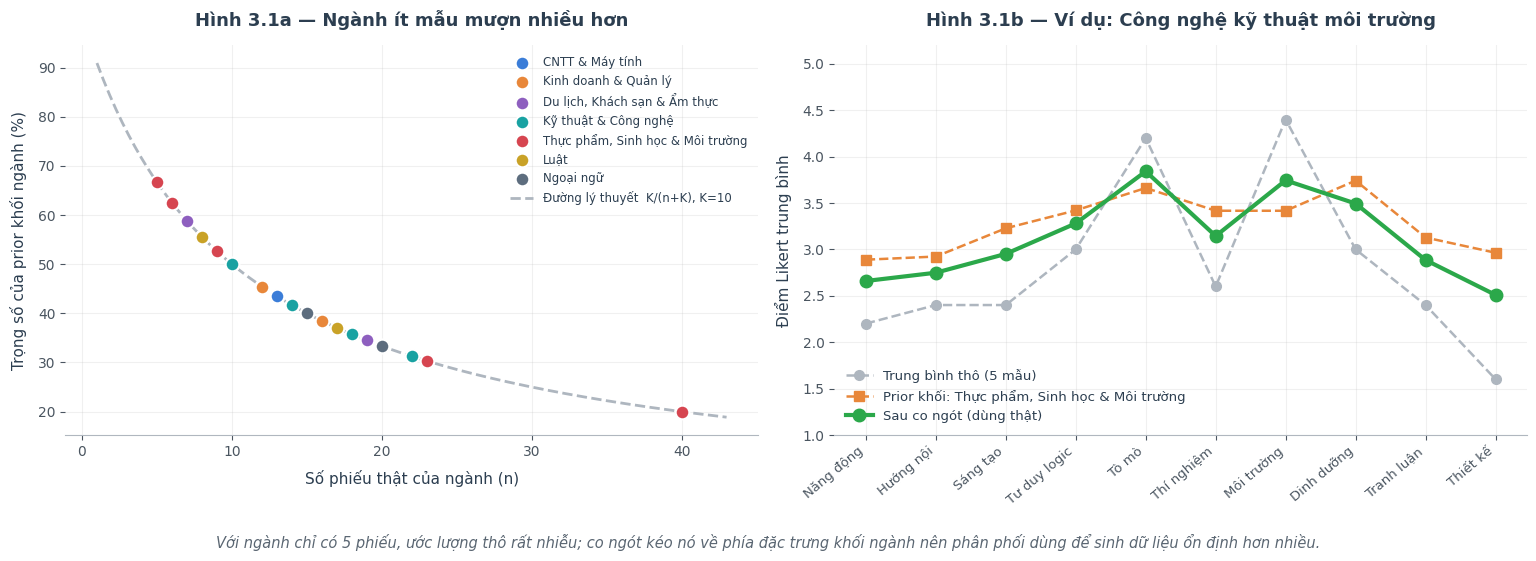

In [4]:
# ═══════════ HÌNH 3.1 — Cơ chế Bayesian Shrinkage ═══════════
fig, axes = plt.subplots(1, 2, figsize=(15.5, 5.3))

# (a) Quan hệ số mẫu ↔ trọng số prior
ax = axes[0]
n_mau = np.array([d["so_mau_thuc_te"] for d in phan_phoi.values()])
w_pri = np.array([d["trong_so_prior"] for d in phan_phoi.values()]) * 100
kh_id = np.array([d["khoi_nganh_id"] for d in phan_phoi.values()])
for k in range(7):
    m = kh_id == k
    ax.scatter(n_mau[m], w_pri[m], s=95, color=C_KHOI[k], edgecolor="white",
               linewidth=1.4, label=TEN_KHOI[k], zorder=3)
xx = np.linspace(1, n_mau.max() + 3, 200)
ax.plot(xx, K_NGANH / (xx + K_NGANH) * 100, "--", color=C_XAM, lw=2,
        label=f"Đường lý thuyết  K/(n+K), K={K_NGANH:.0f}", zorder=2)
ax.set_xlabel("Số phiếu thật của ngành (n)")
ax.set_ylabel("Trọng số của prior khối ngành (%)")
ax.set_title("Hình 3.1a — Ngành ít mẫu mượn nhiều hơn")
ax.legend(fontsize=8.5, loc="upper right"); ax.set_axisbelow(True)

# (b) Ví dụ: ngành ít mẫu bị kéo về khối như thế nào
ax = axes[1]
ma_it = min(phan_phoi, key=lambda m: phan_phoi[m]["so_mau_thuc_te"])
d = phan_phoi[ma_it]; k = d["khoi_nganh_id"]
tho = df_train[df_train["ma_nganh"] == int(ma_it)][LIKERT_COLS].mean().values
x = np.arange(10)
ax.plot(x, tho, "o--", color=C_XAM, lw=1.8, ms=7, label=f"Trung bình thô ({d['so_mau_thuc_te']} mẫu)")
ax.plot(x, khoi_stats[k]["mean"], "s--", color=C_CAM, lw=1.8, ms=7,
        label=f"Prior khối: {TEN_KHOI[k]}")
ax.plot(x, d["likert_mean"], "o-", color=C_GA, lw=3, ms=9, label="Sau co ngót (dùng thật)")
ax.set_xticks(x); ax.set_xticklabels(NHAN, rotation=40, ha="right", fontsize=9.5)
ax.set_ylabel("Điểm Likert trung bình"); ax.set_ylim(1, 5.2)
ax.set_title(f"Hình 3.1b — Ví dụ: {d['ten_nganh']}")
ax.legend(fontsize=9.5, loc="lower left"); ax.set_axisbelow(True)

plt.tight_layout()
luu(fig, DIST_DIR, "hinh_3_1_bayesian_shrinkage.png",
    f"Với ngành chỉ có {n_mau.min()} phiếu, ước lượng thô rất nhiễu; co ngót kéo nó về phía đặc trưng "
    "khối ngành nên phân phối dùng để sinh dữ liệu ổn định hơn nhiều.")
plt.show()

## 2. Cấu trúc tương quan giữa 10 câu hỏi

Đây là thứ mà cách lưu "trung bình + độ lệch chuẩn từng câu" **không thể** giữ được, và cũng là lý do
chính phải dùng ma trận hiệp phương sai.

In [5]:
X_all = df_train[LIKERT_COLS].to_numpy(float)
corr_that = np.corrcoef(X_all, rowvar=False)
iu = np.triu_indices(10, k=1)

covs = np.array([np.array(d["likert_cov"]) for d in phan_phoi.values()])
ws   = np.array([d["so_mau_thuc_te"] for d in phan_phoi.values()], float)
cov_tb = np.average(covs, axis=0, weights=ws)
dg = np.sqrt(np.diag(cov_tb))
corr_hoc = cov_tb / np.outer(dg, dg)

cap = sorted([(abs(corr_that[i, j]), corr_that[i, j], NHAN[i], NHAN[j]) for i, j in zip(*iu)],
             reverse=True)
print("BẢNG 3.2 — Các cặp câu hỏi có liên hệ mạnh nhất trong dữ liệu thật\n")
print(f"{'Cặp câu hỏi':<34}{'Hệ số tương quan r':>20}")
for a, r, c1, c2 in cap[:8]:
    print(f"{c1 + '  ↔  ' + c2:<34}{r:>+20.3f}")
print(f"\n|r| trung bình của toàn bộ 45 cặp : {np.abs(corr_that[iu]).mean():.3f}")
print(f"|r| trong phân phối đã học        : {np.abs(corr_hoc[iu]).mean():.3f}")
print(f"Sai lệch trung bình               : {np.abs(corr_hoc[iu] - corr_that[iu]).mean():.3f}")

BẢNG 3.2 — Các cặp câu hỏi có liên hệ mạnh nhất trong dữ liệu thật

Cặp câu hỏi                         Hệ số tương quan r
Thí nghiệm  ↔  Môi trường                       +0.615
Môi trường  ↔  Dinh dưỡng                       +0.560
Môi trường  ↔  Thiết kế                         +0.510
Thí nghiệm  ↔  Dinh dưỡng                       +0.507
Tranh luận  ↔  Thiết kế                         +0.454
Dinh dưỡng  ↔  Thiết kế                         +0.444
Môi trường  ↔  Tranh luận                       +0.414
Tò mò  ↔  Thí nghiệm                            +0.368

|r| trung bình của toàn bộ 45 cặp : 0.237
|r| trong phân phối đã học        : 0.253
Sai lệch trung bình               : 0.033


   💾 Đã lưu hình: hinh_3_2_ma_tran_tuong_quan.png


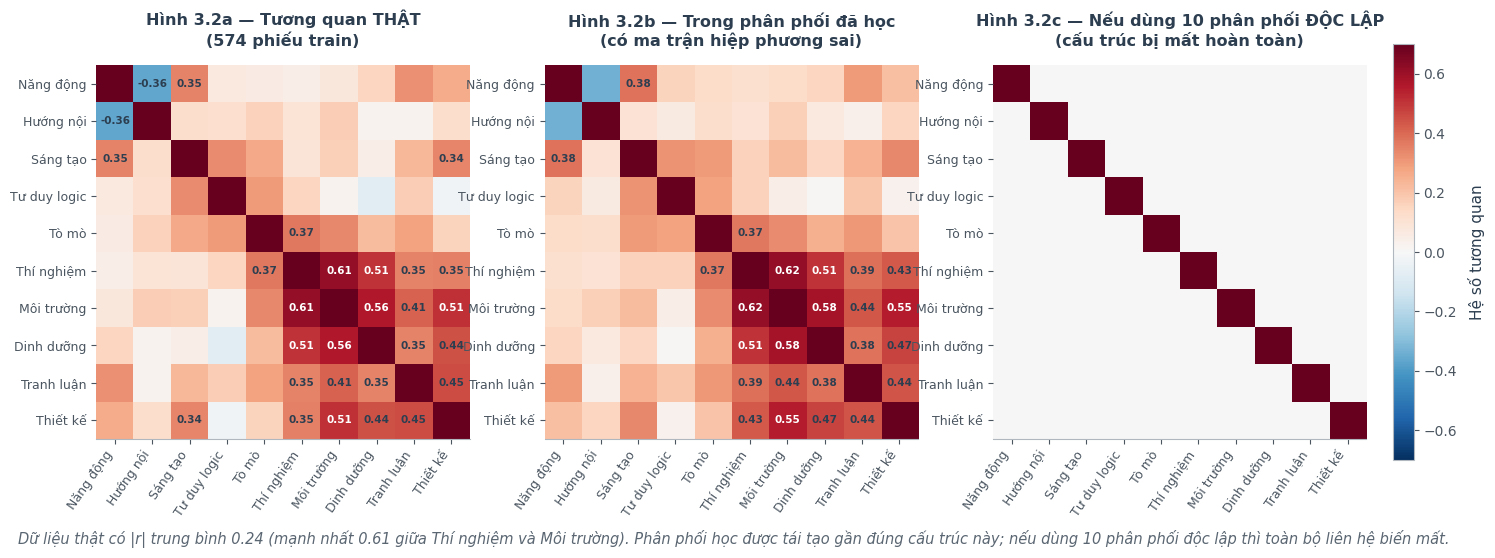

In [6]:
# ═══════════ HÌNH 3.2 — Ma trận tương quan ═══════════
fig, axes = plt.subplots(1, 3, figsize=(17, 5.4))

for ax, M, tieu_de in zip(
    axes, [corr_that, corr_hoc, np.eye(10)],
    ["Hình 3.2a — Tương quan THẬT\n(574 phiếu train)",
     "Hình 3.2b — Trong phân phối đã học\n(có ma trận hiệp phương sai)",
     "Hình 3.2c — Nếu dùng 10 phân phối ĐỘC LẬP\n(cấu trúc bị mất hoàn toàn)"]):
    im = ax.imshow(M, cmap="RdBu_r", vmin=-0.7, vmax=0.7)
    ax.set_xticks(range(10)); ax.set_xticklabels(NHAN, rotation=55, ha="right", fontsize=9)
    ax.set_yticks(range(10)); ax.set_yticklabels(NHAN, fontsize=9)
    ax.set_title(tieu_de, fontsize=11.5)
    ax.grid(False)
    for i in range(10):
        for j in range(10):
            if i != j and abs(M[i, j]) > 0.34:
                ax.text(j, i, f"{M[i,j]:.2f}", ha="center", va="center",
                        fontsize=7.5, fontweight="bold",
                        color="white" if abs(M[i, j]) > 0.5 else C_DAM)
fig.colorbar(im, ax=axes, fraction=0.016, pad=0.02, label="Hệ số tương quan")

luu(fig, DIST_DIR, "hinh_3_2_ma_tran_tuong_quan.png",
    f"Dữ liệu thật có |r| trung bình {np.abs(corr_that[iu]).mean():.2f} (mạnh nhất {cap[0][1]:.2f} giữa "
    f"{cap[0][2]} và {cap[0][3]}). Phân phối học được tái tạo gần đúng cấu trúc này; "
    "nếu dùng 10 phân phối độc lập thì toàn bộ liên hệ biến mất.")
plt.show()

   💾 Đã lưu hình: hinh_3_3_ho_so_khoi_nganh.png


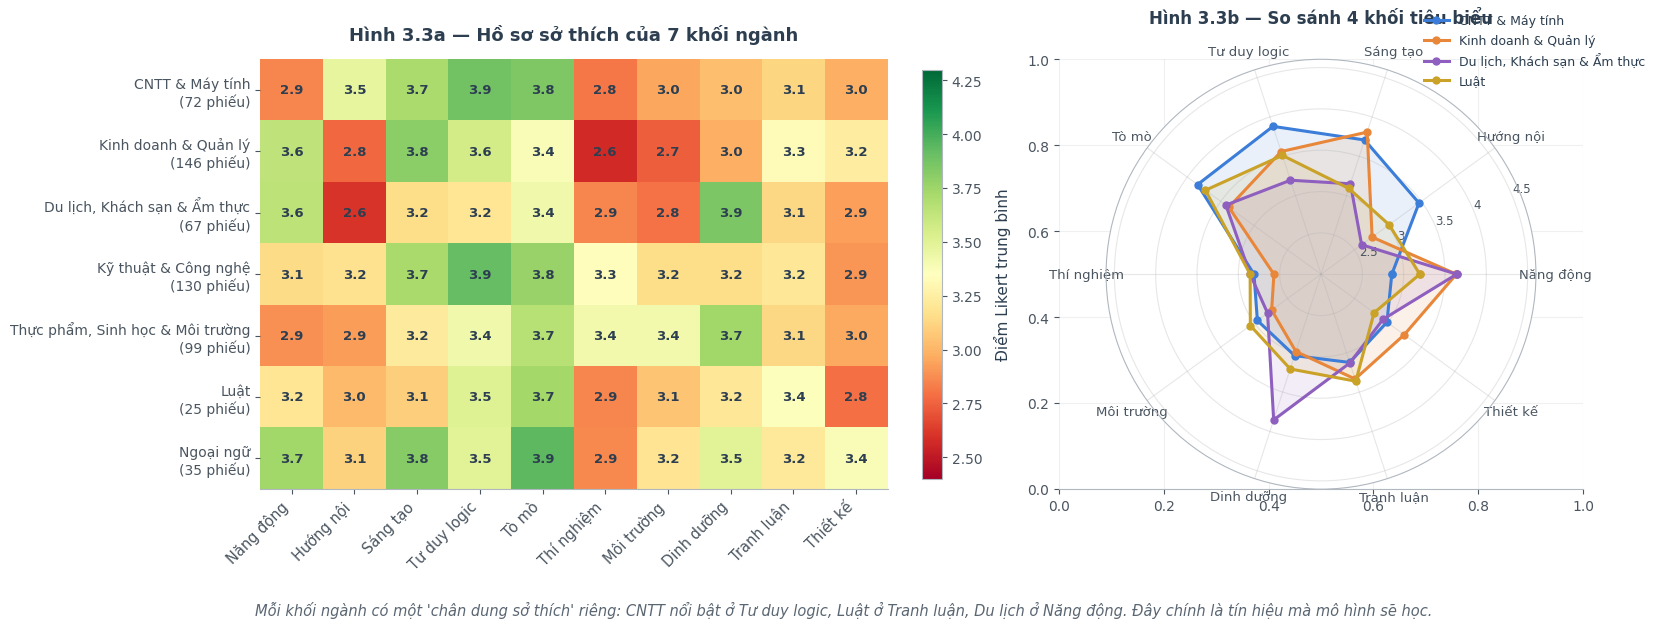

In [7]:
# ═══════════ HÌNH 3.3 — Hồ sơ sở thích của 7 khối ngành ═══════════
M = np.array([khoi_stats[k]["mean"] for k in range(7)])
fig, axes = plt.subplots(1, 2, figsize=(17, 6), gridspec_kw={"width_ratios": [1.3, 1]})

# (a) Heatmap
ax = axes[0]
im = ax.imshow(M, cmap="RdYlGn", aspect="auto", vmin=2.4, vmax=4.3)
ax.set_xticks(range(10)); ax.set_xticklabels(NHAN, rotation=45, ha="right", fontsize=10.5)
ax.set_yticks(range(7))
ax.set_yticklabels([f"{TEN_KHOI[k]}\n({khoi_stats[k]['n']} phiếu)" for k in range(7)], fontsize=10)
for i in range(7):
    for j in range(10):
        ax.text(j, i, f"{M[i,j]:.1f}", ha="center", va="center", fontsize=9.5,
                fontweight="bold", color=C_DAM)
plt.colorbar(im, ax=ax, fraction=0.03, label="Điểm Likert trung bình")
ax.set_title("Hình 3.3a — Hồ sơ sở thích của 7 khối ngành")
ax.grid(False)

# (b) Radar so sánh vài khối tiêu biểu
ax = fig.add_subplot(1, 2, 2, projection="polar")
goc = np.linspace(0, 2 * np.pi, 10, endpoint=False)
goc_kin = np.r_[goc, goc[0]]
for k in [0, 1, 2, 5]:
    v = np.r_[M[k], M[k][0]]
    ax.plot(goc_kin, v, "o-", lw=2.2, ms=5, color=C_KHOI[k], label=TEN_KHOI[k])
    ax.fill(goc_kin, v, color=C_KHOI[k], alpha=0.11)
ax.set_xticks(goc); ax.set_xticklabels(NHAN, fontsize=9.5)
ax.set_ylim(2, 4.6); ax.set_yticks([2.5, 3, 3.5, 4, 4.5])
ax.set_yticklabels(["2.5", "3", "3.5", "4", "4.5"], fontsize=8.5)
ax.set_title("Hình 3.3b — So sánh 4 khối tiêu biểu", pad=26, fontsize=12)
ax.legend(loc="upper right", bbox_to_anchor=(1.28, 1.13), fontsize=9)
ax.grid(alpha=0.3)

plt.tight_layout()
luu(fig, DIST_DIR, "hinh_3_3_ho_so_khoi_nganh.png",
    "Mỗi khối ngành có một 'chân dung sở thích' riêng: CNTT nổi bật ở Tư duy logic, "
    "Luật ở Tranh luận, Du lịch ở Năng động. Đây chính là tín hiệu mà mô hình sẽ học.")
plt.show()

## 3. Phân phối riêng cho từng fold

Phân phối ở trên học từ **cả 574 phiếu**. Nếu dùng nó để sinh dữ liệu rồi lại đem đo Cross-Validation
thì dòng tổng hợp trong TRAIN của một fold đã "biết" đôi chút về dòng thật nằm trong VAL của fold đó,
làm chỉ số **lạc quan hơn thực tế**.

Vì vậy ta học thêm một bộ phân phối **cho mỗi fold, chỉ từ phần train của fold đó**. Giai đoạn 4 sẽ
sinh dữ liệu tương ứng và Giai đoạn 8 dùng đúng bộ của fold khi chạy CV.

In [8]:
phan_phoi_fold = {}
for f in CV["folds"]:
    pp, _, _ = hoc_phan_phoi(df_train.iloc[f["train_idx"]])
    phan_phoi_fold[str(f["fold"])] = pp

lech = np.array([
    np.abs(np.array(pp[ma]["likert_mean"]) - np.array(phan_phoi[ma]["likert_mean"])).mean()
    for pp in phan_phoi_fold.values() for ma in phan_phoi])

print(f"✅ Đã học phân phối riêng cho {len(phan_phoi_fold)} fold")
print(f"   Sai lệch vector trung bình so với bộ 'sản xuất':")
print(f"      trung bình {lech.mean():.4f} điểm Likert  |  lớn nhất {lech.max():.4f}")
print(f"   → Sai lệch nhỏ, nhưng vẫn tách riêng để chỉ số CV không bị lạc quan.")

✅ Đã học phân phối riêng cho 15 fold
   Sai lệch vector trung bình so với bộ 'sản xuất':
      trung bình 0.0736 điểm Likert  |  lớn nhất 0.2087
   → Sai lệch nhỏ, nhưng vẫn tách riêng để chỉ số CV không bị lạc quan.


In [9]:
# --- Xuất file ----------------------------------------------------------------
meta = {"nguon": "02_split/khaosat_train.csv", "so_dong_train": len(df_train),
        "K_NGANH": K_NGANH, "K_KHOI": K_KHOI, "VAR_MIN": VAR_MIN,
        "likert_cols": LIKERT_COLS, "muc_tieu_keys": MUC_TIEU_KEYS,
        "ghi_chu": "likert_cov là ma trận hiệp phương sai 10x10, giữ tương quan giữa các câu."}

json.dump({"meta": meta,
           "khoi": {str(k): {"mean": np.round(v["mean"], 4).tolist(),
                             "cov": np.round(v["cov"], 4).tolist(),
                             "n": v["n"], "ten": TEN_KHOI[k]} for k, v in khoi_stats.items()},
           "theo_nganh": phan_phoi},
          open(DIST_DIR / "phan_phoi_theo_nganh.json", "w", encoding="utf-8"),
          ensure_ascii=False, indent=1)
json.dump({"meta": meta, "theo_fold": phan_phoi_fold},
          open(DIST_DIR / "phan_phoi_theo_fold.json", "w", encoding="utf-8"),
          ensure_ascii=False, indent=1)

# --- Kiểm tra bắt buộc --------------------------------------------------------
for ma, d in phan_phoi.items():
    C = np.array(d["likert_cov"])
    assert C.shape == (10, 10), f"{ma}: hiệp phương sai phải 10×10"
    assert np.allclose(C, C.T, atol=1e-6), f"{ma}: phải đối xứng"
    assert np.linalg.eigvalsh(C).min() > 0, f"{ma}: phải xác định dương"
    assert 1 <= min(d["likert_mean"]) and max(d["likert_mean"]) <= 5
    assert abs(sum(d["muc_tieu_phan_phoi"].values()) - 1) < 1e-4

print("═" * 68)
print("  TÓM TẮT GIAI ĐOẠN 3")
print("═" * 68)
print(f"  Số phiếu dùng để học          {len(df_train):>10}")
print(f"  Số ngành có phân phối         {len(phan_phoi):>10} / 39")
print(f"  Dạng phân phối                {'trung bình (10) + hiệp phương sai (10×10)':>10}")
print(f"  |r| trung bình — thật         {np.abs(corr_that[iu]).mean():>10.3f}")
print(f"  |r| trung bình — đã học       {np.abs(corr_hoc[iu]).mean():>10.3f}")
print(f"  Số bộ phân phối theo fold     {len(phan_phoi_fold):>10}")
print(f"  ✔ 39 ma trận hiệp phương sai đều đối xứng và xác định dương")
print("═" * 68)
print(f"\n  Hình đã lưu tại: {DIST_DIR}/")

════════════════════════════════════════════════════════════════════
  TÓM TẮT GIAI ĐOẠN 3
════════════════════════════════════════════════════════════════════
  Số phiếu dùng để học                 574
  Số ngành có phân phối                 39 / 39
  Dạng phân phối                trung bình (10) + hiệp phương sai (10×10)
  |r| trung bình — thật              0.237
  |r| trung bình — đã học            0.253
  Số bộ phân phối theo fold             15
  ✔ 39 ma trận hiệp phương sai đều đối xứng và xác định dương
════════════════════════════════════════════════════════════════════

  Hình đã lưu tại: ../data/processed/03_distribution/
